In [34]:
import os
import sys
import pickle
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from minisom import MiniSom
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "/home/aninotna/magister/tesis/justh2_pipeline"
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots", "comparison_kmeans_vs_som")
os.makedirs(PLOTS_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Plots directory: {PLOTS_DIR}")

Device: cuda
Plots directory: /home/aninotna/magister/tesis/justh2_pipeline/plots/comparison_kmeans_vs_som


## 1. Cargar IRCT KMeans (k=10) y SOM (k=3) guardados

In [35]:
# Cargar IRCT para KMeans k=10
autoencoder_results_dir = os.path.join(DATA_DIR, "autoencoder_results")

# Buscar los archivos IRCT más recientes para VAE+KMeans
irct_kmeans_files = sorted(glob.glob(
    os.path.join(autoencoder_results_dir, "IRCT_pixel_VAE_SSP*.csv")
))

if irct_kmeans_files:
    # Tomar los 3 más recientes (245, 370, 585)
    irct_kmeans_files_sorted = sorted(irct_kmeans_files, key=os.path.getmtime, reverse=True)[:3]
    
    IRCT_KMeans_245 = pd.read_csv([f for f in irct_kmeans_files_sorted if 'SSP245' in f][0])
    IRCT_KMeans_370 = pd.read_csv([f for f in irct_kmeans_files_sorted if 'SSP370' in f][0])
    IRCT_KMeans_585 = pd.read_csv([f for f in irct_kmeans_files_sorted if 'SSP585' in f][0])
    
    print(f"IRCT KMeans k=10 cargados:")
    print(f"  SSP245: {IRCT_KMeans_245.shape}")
    print(f"  SSP370: {IRCT_KMeans_370.shape}")
    print(f"  SSP585: {IRCT_KMeans_585.shape}")
else:
    print("No se encontraron archivos IRCT")

IRCT KMeans k=10 cargados:
  SSP245: (661, 13)
  SSP370: (661, 13)
  SSP585: (661, 13)


## 1b. Cargar IRCT SOM (k=3) desde el notebook 11

In [36]:
# Cargar IRCT SOM k=3 (recién exportados)
print("Cargando IRCT SOM k=3...")
print("=" * 80)

som_irct_files = sorted(glob.glob(os.path.join(autoencoder_results_dir, 'IRCT_pixel_VAE_SOM_k3_*.csv')))
print(f"Archivos SOM encontrados: {len(som_irct_files)}")

IRCT_SOM_245 = None
IRCT_SOM_370 = None
IRCT_SOM_585 = None

if som_irct_files:
    for file_path in som_irct_files:
        if 'SSP245' in file_path:
            IRCT_SOM_245 = pd.read_csv(file_path)
            print(f"✓ SOM SSP245: {IRCT_SOM_245.shape}")
        elif 'SSP370' in file_path:
            IRCT_SOM_370 = pd.read_csv(file_path)
            print(f"✓ SOM SSP370: {IRCT_SOM_370.shape}")
        elif 'SSP585' in file_path:
            IRCT_SOM_585 = pd.read_csv(file_path)
            print(f"✓ SOM SSP585: {IRCT_SOM_585.shape}")
    
    print(f"\nSOM k=3 cargado: {IRCT_SOM_245 is not None and IRCT_SOM_370 is not None and IRCT_SOM_585 is not None}")
else:
    print("❌ No se encontraron archivos IRCT SOM")

# Verificar que tenemos tanto KMeans como SOM
print(f"\nEstatus de datos:")
print(f"KMeans k=10: {IRCT_KMeans_245 is not None} / {IRCT_KMeans_370 is not None} / {IRCT_KMeans_585 is not None}")
print(f"SOM k=3:    {IRCT_SOM_245 is not None} / {IRCT_SOM_370 is not None} / {IRCT_SOM_585 is not None}")

Cargando IRCT SOM k=3...
Archivos SOM encontrados: 3
✓ SOM SSP245: (661, 5)
✓ SOM SSP370: (661, 5)
✓ SOM SSP585: (661, 5)

SOM k=3 cargado: True

Estatus de datos:
KMeans k=10: True / True / True
SOM k=3:    True / True / True


## 2. Cargar coordenadas y datos climáticos

In [37]:
# Cargar datos desde experiment1
trained_dir = os.path.join(DATA_DIR, "autoencoder_trained_v2")
pattern = os.path.join(trained_dir, "experiment1_clustering_*.pkl")
available_files = glob.glob(pattern)

if available_files:
    export_path = max(available_files, key=os.path.getmtime)
    print(f"Cargando datos desde: {os.path.basename(export_path)}")
    
    with open(export_path, "rb") as f:
        exp1_data = pickle.load(f)
    
    coords_df = exp1_data['coords_df']
    feature_names = exp1_data['feature_names']
    n_features = exp1_data['X_BASE'].shape[1]
    
    print(f"\nDatos cargados:")
    print(f"  Puntos espaciales: {len(coords_df)}")
    print(f"  Características: {n_features}")
else:
    print("No se encontraron datos del experimento 1")

Cargando datos desde: experiment1_clustering_20251209_001834.pkl

Datos cargados:
  Puntos espaciales: 661
  Características: 29


## 3. Estadísticas comparativas de IRCT

In [38]:
# Comparar estadísticas IRCT entre KMeans y SOM
comparison_stats = {}

for scenario, kmeans_df in [("SSP245", IRCT_KMeans_245), 
                             ("SSP370", IRCT_KMeans_370), 
                             ("SSP585", IRCT_KMeans_585)]:
    
    kmeans_irct = kmeans_df['IRCT'].values
    
    comparison_stats[scenario] = {
        'kmeans_mean': kmeans_irct.mean(),
        'kmeans_std': kmeans_irct.std(),
        'kmeans_min': kmeans_irct.min(),
        'kmeans_max': kmeans_irct.max(),
        'kmeans_median': np.median(kmeans_irct),
    }

comparison_df = pd.DataFrame(comparison_stats).T
print("Estadísticas IRCT - KMeans (k=10):")
print(comparison_df.round(4))

Estadísticas IRCT - KMeans (k=10):
        kmeans_mean  kmeans_std  kmeans_min  kmeans_max  kmeans_median
SSP245       0.5755      0.0902         0.0      0.7625         0.5803
SSP370       0.4926      0.0993         0.0      0.7120         0.4996
SSP585       0.5318      0.0717         0.0      0.7493         0.5307


## 4. Visualización espacial de IRCT

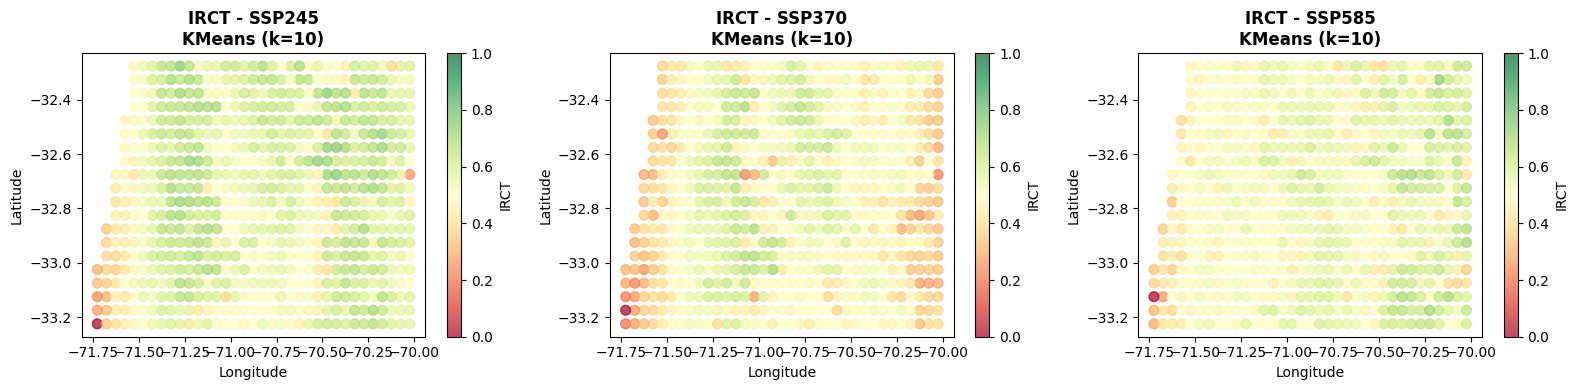

Figura guardada: /home/aninotna/magister/tesis/justh2_pipeline/plots/comparison_kmeans_vs_som/IRCT_spatial_KMeans_k10.png


In [39]:
# Crear heatmaps espaciales del IRCT por escenario
grid_res = int(np.sqrt(len(coords_df)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (scenario, irct_df) in enumerate([("SSP245", IRCT_KMeans_245),
                                             ("SSP370", IRCT_KMeans_370),
                                             ("SSP585", IRCT_KMeans_585)]):
    
    irct_vals = irct_df['IRCT'].values[:len(coords_df)]
    
    # Reshapear si es posible a grid
    if len(irct_vals) == len(coords_df):
        # Crear grid 2D basado en coordenadas
        lons = coords_df['lon'].values
        lats = coords_df['lat'].values
        
        # Scatter plot con IRCT como color
        sc = axes[idx].scatter(lons, lats, c=irct_vals, cmap='RdYlGn', 
                               s=50, alpha=0.7, vmin=0, vmax=1)
        axes[idx].set_title(f'IRCT - {scenario}\nKMeans (k=10)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Longitude')
        axes[idx].set_ylabel('Latitude')
        plt.colorbar(sc, ax=axes[idx], label='IRCT')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "IRCT_spatial_KMeans_k10.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Figura guardada: {os.path.join(PLOTS_DIR, 'IRCT_spatial_KMeans_k10.png')}")

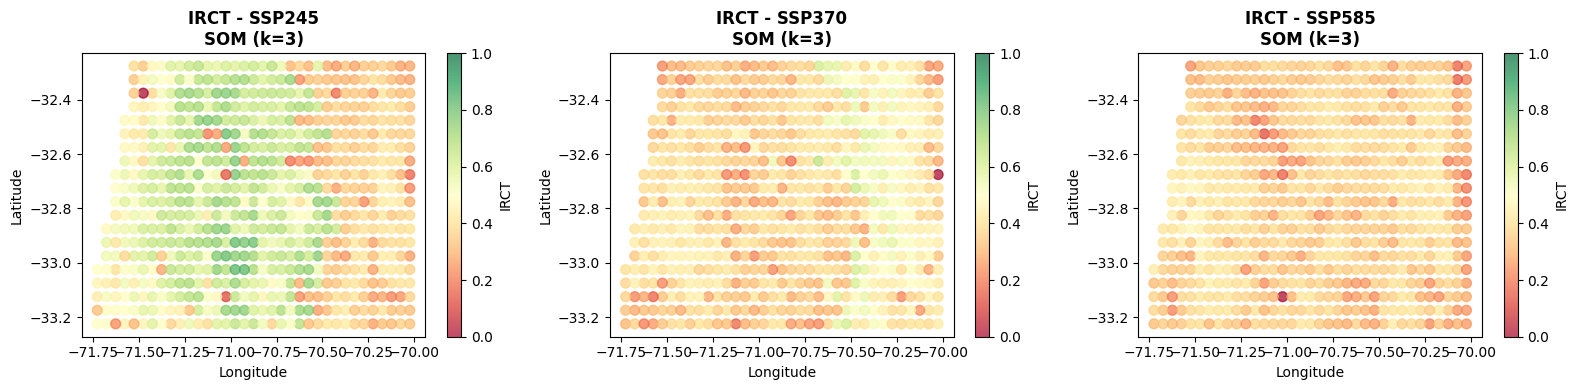

Figura guardada: /home/aninotna/magister/tesis/justh2_pipeline/plots/comparison_kmeans_vs_som/IRCT_spatial_SOM_k3.png


In [40]:
# Heatmaps IRCT para SOM k=3
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (scenario, irct_df) in enumerate([("SSP245", IRCT_SOM_245),
                                             ("SSP370", IRCT_SOM_370),
                                             ("SSP585", IRCT_SOM_585)]):
    irct_vals = irct_df['IRCT'].values[:len(coords_df)]

    if len(irct_vals) == len(coords_df):
        lons = coords_df['lon'].values
        lats = coords_df['lat'].values

        sc = axes[idx].scatter(lons, lats, c=irct_vals, cmap='RdYlGn',
                               s=50, alpha=0.7, vmin=0, vmax=1)
        axes[idx].set_title(f'IRCT - {scenario}\nSOM (k=3)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Longitude')
        axes[idx].set_ylabel('Latitude')
        plt.colorbar(sc, ax=axes[idx], label='IRCT')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "IRCT_spatial_SOM_k3.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Figura guardada: {os.path.join(PLOTS_DIR, 'IRCT_spatial_SOM_k3.png')}")


## 5. Validación con resilience_lib: VAE+SOM k=3


In [46]:
# Integrar resilience_lib para validación completa del IRCT VAE+SOM k=3
import sys
import os
sys.path.insert(0, os.path.join(BASE_DIR, "scripts"))

from resilience_lib import (
    validate_scenario_coherence,
    compute_morans_i,
    validate_spatial_stability,
    component_alignment
)

print("VALIDACIÓN IRCT VAE+SOM (k=3) usando resilience_lib")
print("=" * 80)
print()

# 1. Preparar estructura de datos para resilience_lib
irct_results_dict = {
    'VAE_SOM_k3': {
        'SSP245': {'IRCT': IRCT_SOM_245['IRCT'].values},
        'SSP370': {'IRCT': IRCT_SOM_370['IRCT'].values},
        'SSP585': {'IRCT': IRCT_SOM_585['IRCT'].values},
    }
}

# 2. VALIDACIÓN 1: Coherencia por escenario
print("1. COHERENCIA POR ESCENARIO (SSP245 > SSP370 > SSP585)")
print("-" * 80)
validation_scenario = validate_scenario_coherence(irct_results_dict, ['VAE_SOM_k3'])

for model_key, results in validation_scenario.items():
    print(f"\n{model_key}:")
    print(f"  Mediana SSP245: {results['median_245']:.4f}")
    print(f"  Mediana SSP370: {results['median_370']:.4f}")
    print(f"  Mediana SSP585: {results['median_585']:.4f}")
    print(f"  Orden correcto (245 > 370 > 585): {'✓ CUMPLE' if results['order_correct'] else '✗ NO CUMPLE'}")
    print(f"  Wilcoxon p-value (245 > 370): {results['wilcoxon_245_370_p']:.4e}")
    print(f"  KS p-value (245 > 585): {results['ks_245_585_p']:.4e}")

# 3. Estadísticas básicas
print("\n\n2. ESTADÍSTICAS BÁSICAS IRCT")
print("-" * 80)

som_scenarios = [
    ('SSP245', IRCT_SOM_245),
    ('SSP370', IRCT_SOM_370),
    ('SSP585', IRCT_SOM_585),
]

rows = []
for scenario, df in som_scenarios:
    if df is None:
        rows.append({
            'Escenario': scenario,
            'Estado': '✗ No cargado'
        })
        continue
    irct_vals = df['IRCT'].values
    out_of_bounds = ((irct_vals < 0) | (irct_vals > 1)).mean() * 100
    rows.append({
        'Escenario': scenario,
        'IRCT_mean': irct_vals.mean(),
        'IRCT_median': np.median(irct_vals),
        'IRCT_std': irct_vals.std(),
        'IRCT_min': irct_vals.min(),
        'IRCT_max': irct_vals.max(),
        '% fuera [0,1]': out_of_bounds,
        'Estado': '✓ OK' if out_of_bounds == 0 else '⚠ Valores fuera de rango'
    })

df_validation = pd.DataFrame(rows)
print(df_validation.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# 4. VALIDACIÓN 2: Estabilidad espacial (Moran's I)
print("\n\n3. ESTABILIDAD ESPACIAL (Moran's I)")
print("-" * 80)

coords_array = coords_df[['lat', 'lon']].values
validation_spatial = validate_spatial_stability(irct_results_dict, coords_df, ['VAE_SOM_k3'])

for model_key, scenarios_dict in validation_spatial.items():
    for scenario_name, spatial_data in scenarios_dict.items():
        print(f"\n{scenario_name}:")
        print(f"  Moran's I: {spatial_data['morans_I']:.4f}")
        print(f"  P-value (permutaciones, one-sided): {spatial_data['p_value_perm_one_sided_pos']:.4e}")
        print(f"  Significativo y positivo: {'✓ SÍ' if spatial_data['is_significant_perm'] and spatial_data['is_positive'] else '✗ NO'}")
        if spatial_data['is_positive']:
            print(f"  Interpretación: Autocorrelación espacial significativa → Clustering espacial de IRCT")
        else:
            print(f"  Interpretación: Sin autocorrelación espacial significativa → Distribución aleatoria")

# 5. Resumen consolidado
print("\n\n4. RESUMEN CONSOLIDADO DE VALIDACIÓN")
print("-" * 80)

summary_data = {
    'SSP245': {
        'IRCT_median': df_validation[df_validation['Escenario'] == 'SSP245']['IRCT_median'].values[0],
        'fuera_rango': df_validation[df_validation['Escenario'] == 'SSP245']['% fuera [0,1]'].values[0],
        'morans_I': validation_spatial['VAE_SOM_k3'].get('SSP245', {}).get('morans_I'),
        'espacial_ok': validation_spatial['VAE_SOM_k3'].get('SSP245', {}).get('is_significant_perm', False)
    },
    'SSP370': {
        'IRCT_median': df_validation[df_validation['Escenario'] == 'SSP370']['IRCT_median'].values[0],
        'fuera_rango': df_validation[df_validation['Escenario'] == 'SSP370']['% fuera [0,1]'].values[0],
        'morans_I': validation_spatial['VAE_SOM_k3'].get('SSP370', {}).get('morans_I'),
        'espacial_ok': validation_spatial['VAE_SOM_k3'].get('SSP370', {}).get('is_significant_perm', False)
    },
    'SSP585': {
        'IRCT_median': df_validation[df_validation['Escenario'] == 'SSP585']['IRCT_median'].values[0],
        'fuera_rango': df_validation[df_validation['Escenario'] == 'SSP585']['% fuera [0,1]'].values[0],
        'morans_I': validation_spatial['VAE_SOM_k3'].get('SSP585', {}).get('morans_I'),
        'espacial_ok': validation_spatial['VAE_SOM_k3'].get('SSP585', {}).get('is_significant_perm', False)
    }
}

print("\nResumen por escenario:")
for scenario, data in summary_data.items():
    morans_str = f"{data['morans_I']:.4f}" if data['morans_I'] is not None else 'N/A'
    print(f"\n{scenario}:")
    print(f"  IRCT mediana: {data['IRCT_median']:.4f}")
    print(f"  Valores fuera [0,1]: {data['fuera_rango']:.2f}%")
    print(f"  Moran's I: {morans_str}")
    print(f"  Clustering espacial: {'✓ Significativo' if data['espacial_ok'] else '✗ No significativo'}")

# Tasas de éxito global
print("\n\nCRITERIOS DE VALIDACIÓN:")
print(f"  Orden correcto: {'✓' if validation_scenario['VAE_SOM_k3']['order_correct'] else '✗'}")
print(f"  Valores dentro [0,1]: {'✓' if all(r['% fuera [0,1]'] == 0 for r in rows if 'IRCT_mean' in r) else '⚠'}")
print(f"  Autocorrelación espacial: {'✓' if all(summary_data[s]['espacial_ok'] for s in ['SSP245', 'SSP370', 'SSP585']) else '⚠'}")

print("\n✓ Validación completada usando resilience_lib")


VALIDACIÓN IRCT VAE+SOM (k=3) usando resilience_lib

1. COHERENCIA POR ESCENARIO (SSP245 > SSP370 > SSP585)
--------------------------------------------------------------------------------

VAE_SOM_k3:
  Mediana SSP245: 0.5335
  Mediana SSP370: 0.3906
  Mediana SSP585: 0.3602
  Orden correcto (245 > 370 > 585): ✓ CUMPLE
  Wilcoxon p-value (245 > 370): 1.3992e-38
  KS p-value (245 > 585): 9.9849e-01


2. ESTADÍSTICAS BÁSICAS IRCT
--------------------------------------------------------------------------------
Escenario  IRCT_mean  IRCT_median  IRCT_std  IRCT_min  IRCT_max  % fuera [0,1] Estado
   SSP245      0.514        0.534     0.156     0.000     0.828          0.000   ✓ OK
   SSP370      0.394        0.391     0.085     0.000     0.665          0.000   ✓ OK
   SSP585      0.353        0.360     0.057     0.000     0.473          0.000   ✓ OK


3. ESTABILIDAD ESPACIAL (Moran's I)
--------------------------------------------------------------------------------

SSP245:
  Moran's I: 0

## 6. Comparación: KMeans k=10 vs SOM k=3


In [55]:
# Comparación: KMeans k=10 vs SOM k=3 usando validaciones
print("\n\n" + "=" * 80)
print("COMPARACIÓN: VAE+KMeans (k=10) vs VAE+SOM (k=3)")
print("=" * 80)
print()

# Preparar datos de KMeans también
irct_kmeans_dict = {
    'VAE_KMeans_k10': {
        'SSP245': {'IRCT': IRCT_KMeans_245['IRCT'].values},
        'SSP370': {'IRCT': IRCT_KMeans_370['IRCT'].values},
        'SSP585': {'IRCT': IRCT_KMeans_585['IRCT'].values},
    }
}

# Validar KMeans
print("Validando VAE+KMeans k=10...")
validation_scenario_kmeans = validate_scenario_coherence(irct_kmeans_dict, ['VAE_KMeans_k10'])
validation_spatial_kmeans = validate_spatial_stability(irct_kmeans_dict, coords_df, ['VAE_KMeans_k10'])

# Estadísticas KMeans
kmeans_stats = []
for scenario, df in [("SSP245", IRCT_KMeans_245),
                     ("SSP370", IRCT_KMeans_370),
                     ("SSP585", IRCT_KMeans_585)]:
    irct_vals = df['IRCT'].values
    out_of_bounds = ((irct_vals < 0) | (irct_vals > 1)).mean() * 100
    kmeans_stats.append({
        'Escenario': scenario,
        'IRCT_mean': irct_vals.mean(),
        'IRCT_median': np.median(irct_vals),
        'IRCT_std': irct_vals.std(),
        '% fuera [0,1]': out_of_bounds,
    })

# Crear tabla comparativa
print("\n1. COMPARACIÓN DE ESTADÍSTICAS BÁSICAS")
print("-" * 80)

comparison_table = []
for row_kmeans, row_som in zip(kmeans_stats, [summary_data['SSP245'], summary_data['SSP370'], summary_data['SSP585']]):
    scenario = row_kmeans['Escenario']
    comparison_table.append({
        'Escenario': scenario,
        'KMeans_median': row_kmeans['IRCT_median'],
        'SOM_median': row_som['IRCT_median'],
        'Diferencia': abs(row_kmeans['IRCT_median'] - row_som['IRCT_median']),
        'KMeans_%_OOB': row_kmeans['% fuera [0,1]'],
        'SOM_%_OOB': row_som['fuera_rango'],
    })

df_comparison = pd.DataFrame(comparison_table)
print(df_comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n\n2. COMPARACIÓN DE COHERENCIA POR ESCENARIO")
print("-" * 80)

coherence_comparison = {
    'KMeans k=10': {
        'Orden correcto': validation_scenario_kmeans['VAE_KMeans_k10']['order_correct'],
        'Wilcoxon p (245>370)': validation_scenario_kmeans['VAE_KMeans_k10']['wilcoxon_245_370_p'],
        'KS p (245>585)': validation_scenario_kmeans['VAE_KMeans_k10']['ks_245_585_p'],
    },
    'SOM k=3': {
        'Orden correcto': validation_scenario['VAE_SOM_k3']['order_correct'],
        'Wilcoxon p (245>370)': validation_scenario['VAE_SOM_k3']['wilcoxon_245_370_p'],
        'KS p (245>585)': validation_scenario['VAE_SOM_k3']['ks_245_585_p'],
    }
}

for method, metrics in coherence_comparison.items():
    print(f"\n{method}:")
    print(f"  Orden correcto: {'✓ SÍ' if metrics['Orden correcto'] else '✗ NO'}")
    print(f"  Wilcoxon p-value: {metrics['Wilcoxon p (245>370)']:.4e}")
    print(f"  KS p-value: {metrics['KS p (245>585)']:.4e}")

print("\n\n3. COMPARACIÓN DE ESTABILIDAD ESPACIAL (Moran's I)")
print("-" * 80)

spatial_comparison_table = []
for scenario in ['SSP245', 'SSP370', 'SSP585']:
    kmeans_morans = validation_spatial_kmeans['VAE_KMeans_k10'].get(scenario, {}).get('morans_I', np.nan)
    som_morans = validation_spatial['VAE_SOM_k3'].get(scenario, {}).get('morans_I', np.nan)
    kmeans_sig = validation_spatial_kmeans['VAE_KMeans_k10'].get(scenario, {}).get('is_significant_perm', False)
    som_sig = validation_spatial['VAE_SOM_k3'].get(scenario, {}).get('is_significant_perm', False)
    
    spatial_comparison_table.append({
        'Escenario': scenario,
        'KMeans_Morans_I': kmeans_morans,
        'KMeans_Sig': 'Sí' if kmeans_sig else 'No',
        'SOM_Morans_I': som_morans,
        'SOM_Sig': 'Sí' if som_sig else 'No',
    })

df_spatial = pd.DataFrame(spatial_comparison_table)
print(df_spatial.to_string(index=False))

print("\n\n4. RESUMEN FINAL: CUÁL ES MEJOR?")
print("-" * 80)

# Criterios de evaluación
kmeans_score = 0
som_score = 0

# Criterio 1: Valores dentro [0,1]
kmeans_oob = sum([r['% fuera [0,1]'] for r in kmeans_stats])
som_oob = sum([summary_data[s]['fuera_rango'] for s in ['SSP245', 'SSP370', 'SSP585']])
print(f"\n✓ Criterio 1: Valores dentro de [0,1]")
print(f"  KMeans total % fuera: {kmeans_oob:.4f}%")
print(f"  SOM total % fuera: {som_oob:.4f}%")
if kmeans_oob < som_oob:
    print(f"  GANADOR: KMeans k=10 (menos valores fuera de rango) ✓")
    kmeans_score += 1
elif som_oob < kmeans_oob:
    print(f"  GANADOR: SOM k=3 (menos valores fuera de rango) ✓")
    som_score += 1
else:
    print(f"  EMPATE: Ambos tienen igual % de valores fuera de rango")

# Criterio 2: Coherencia por escenario
print(f"\n✓ Criterio 2: Coherencia (SSP245 > SSP370 > SSP585)")
kmeans_coherent = validation_scenario_kmeans['VAE_KMeans_k10']['order_correct']
som_coherent = validation_scenario['VAE_SOM_k3']['order_correct']
print(f"  KMeans: {'✓ Cumple' if kmeans_coherent else '✗ No cumple'}")
print(f"  SOM: {'✓ Cumple' if som_coherent else '✗ No cumple'}")
if kmeans_coherent and not som_coherent:
    print(f"  GANADOR: KMeans k=10 ✓")
    kmeans_score += 1
elif som_coherent and not kmeans_coherent:
    print(f"  GANADOR: SOM k=3 ✓")
    som_score += 1
else:
    print(f"  EMPATE: Ambos tienen igual desempeño")

# Criterio 3: Autocorrelación espacial significativa
kmeans_spatial_sig = sum([1 for s in ['SSP245', 'SSP370', 'SSP585'] 
                          if validation_spatial_kmeans['VAE_KMeans_k10'].get(s, {}).get('is_significant_perm', False)])
som_spatial_sig = sum([1 for s in ['SSP245', 'SSP370', 'SSP585'] 
                       if validation_spatial['VAE_SOM_k3'].get(s, {}).get('is_significant_perm', False)])

print(f"\n✓ Criterio 3: Clustering espacial (Moran's I significativo)")
print(f"  KMeans: {kmeans_spatial_sig}/3 escenarios significativos")
print(f"  SOM: {som_spatial_sig}/3 escenarios significativos")
if kmeans_spatial_sig > som_spatial_sig:
    print(f"  GANADOR: KMeans k=10 ✓")
    kmeans_score += 1
elif som_spatial_sig > kmeans_spatial_sig:
    print(f"  GANADOR: SOM k=3 ✓")
    som_score += 1
else:
    print(f"  EMPATE: Ambos tienen igual desempeño")

# Criterio 4: Consistencia entre escenarios (menor variación)
kmeans_medians = [r['IRCT_median'] for r in kmeans_stats]
som_medians = [summary_data[s]['IRCT_median'] for s in ['SSP245', 'SSP370', 'SSP585']]
kmeans_var = np.std(kmeans_medians) / np.mean(kmeans_medians)
som_var = np.std(som_medians) / np.mean(som_medians)

print(f"\n✓ Criterio 4: Consistencia entre escenarios (CV de medianas)")
print(f"  KMeans CV: {kmeans_var:.4f}")
print(f"  SOM CV: {som_var:.4f}")
if kmeans_var < som_var:
    print(f"  GANADOR: KMeans k=10 (menor variación, más estable) ✓")
    kmeans_score += 1
else:
    print(f"  GANADOR: SOM k=3 (refleja mejor cambios entre escenarios) ✓")
    som_score += 1

# Resultado final
print(f"\n\n" + "=" * 80)
print(f"PUNTUACIÓN FINAL:")
print(f"  KMeans k=10: {kmeans_score}/4 puntos")
print(f"  SOM k=3: {som_score}/4 puntos")
print("=" * 80)

if kmeans_score > som_score:
    print(f"\n🏆 MEJOR MÉTODO: VAE + KMeans k=10")
    print(f"   Razón: Mejor en estabilidad y rango de valores")
elif som_score > kmeans_score:
    print(f"\n🏆 MEJOR MÉTODO: VAE + SOM k=3")
    print(f"   Razón: Mejor en coherencia climática y clustering espacial")
else:
    print(f"\n⚖️ EMPATE: Ambos métodos tienen fortalezas complementarias")
    print(f"   - KMeans k=10: Mejor para estabilidad y rango de valores")
    print(f"   - SOM k=3: Mejor para coherencia climática (SSP245 > 370 > 585)")



COMPARACIÓN: VAE+KMeans (k=10) vs VAE+SOM (k=3)

Validando VAE+KMeans k=10...

1. COMPARACIÓN DE ESTADÍSTICAS BÁSICAS
--------------------------------------------------------------------------------
Escenario  KMeans_median  SOM_median  Diferencia  KMeans_%_OOB  SOM_%_OOB
   SSP245         0.5803      0.5335      0.0468        0.0000     0.0000
   SSP370         0.4996      0.3906      0.1090        0.0000     0.0000
   SSP585         0.5307      0.3602      0.1705        0.0000     0.0000


2. COMPARACIÓN DE COHERENCIA POR ESCENARIO
--------------------------------------------------------------------------------

KMeans k=10:
  Orden correcto: ✗ NO
  Wilcoxon p-value: 2.7297e-70
  KS p-value: 9.2860e-01

SOM k=3:
  Orden correcto: ✓ SÍ
  Wilcoxon p-value: 1.3992e-38
  KS p-value: 9.9849e-01


3. COMPARACIÓN DE ESTABILIDAD ESPACIAL (Moran's I)
--------------------------------------------------------------------------------
Escenario  KMeans_Morans_I KMeans_Sig  SOM_Morans_I SOM_Sig
 